In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)

print("Bibliotecas carregadas com sucesso!")

Matplotlib is building the font cache; this may take a moment.


Bibliotecas carregadas com sucesso!


In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"Total de clientes: {df.shape[0]:,}")
print(f"Total de features: {df.shape[1]}")
df.head()

Dataset shape: (7043, 21)
Total de clientes: 7,043
Total de features: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("VALORES NULOS POR COLUNA:")
print("-" * 40)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado!")

print(f"\nDUPLICATAS: {df.duplicated().sum()}")

# Converter TotalCharges para numérico (tem espaços em branco)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nTotalCharges - nulos após conversão: {df['TotalCharges'].isnull().sum()}")

# Preencher nulos com mediana
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("TotalCharges corrigido!")

VALORES NULOS POR COLUNA:
----------------------------------------
Nenhum valor nulo encontrado!

DUPLICATAS: 0

TotalCharges - nulos após conversão: 11
TotalCharges corrigido!


/var/folders/vn/xwvmdl1d1ss06dr1lthlcn100000gn/T/ipykernel_9353/3672591388.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


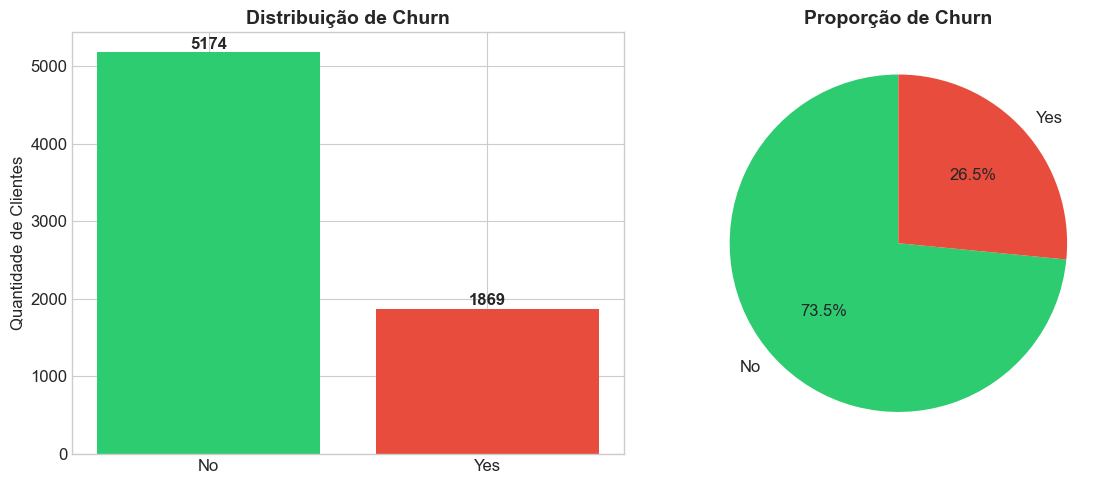


Dataset DESBALANCEADO:
  Não cancelou: 5174 (73.5%)
  Cancelou:     1869 (26.5%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição de Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset DESBALANCEADO:")
print(f"  Não cancelou: {churn_counts.get('No', 0)} ({churn_counts.get('No', 0)/len(df)*100:.1f}%)")
print(f"  Cancelou:     {churn_counts.get('Yes', 0)} ({churn_counts.get('Yes', 0)/len(df)*100:.1f}%)")

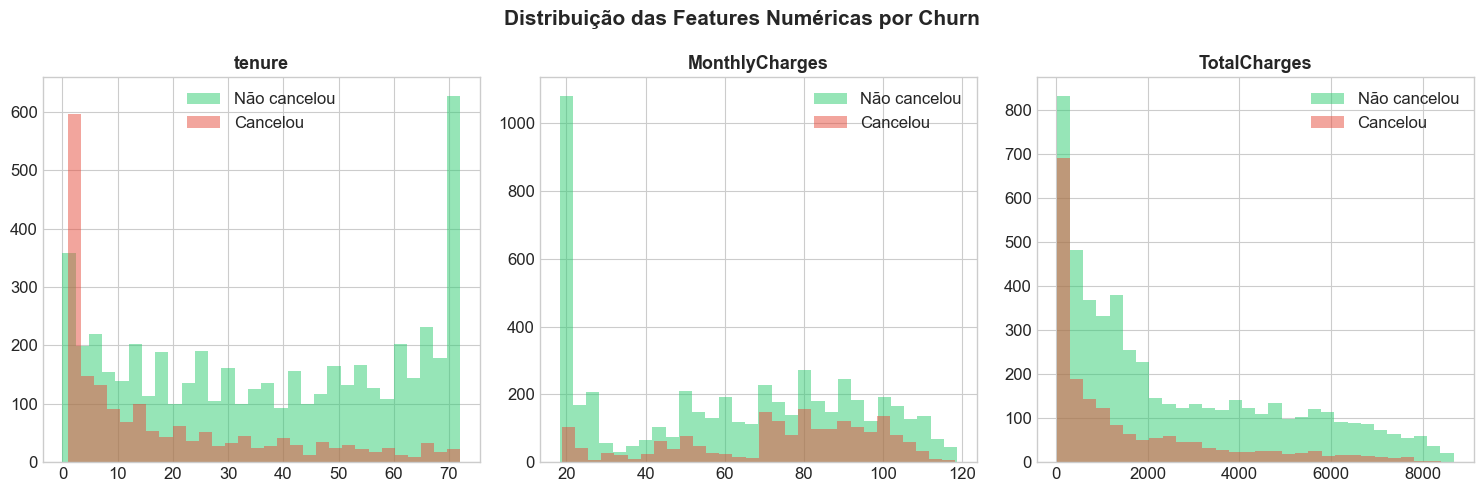

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[df['Churn']=='No'][col], alpha=0.5, label='Não cancelou', color='#2ecc71', bins=30)
    axes[i].hist(df[df['Churn']=='Yes'][col], alpha=0.5, label='Cancelou', color='#e74c3c', bins=30)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend()

plt.suptitle('Distribuição das Features Numéricas por Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()

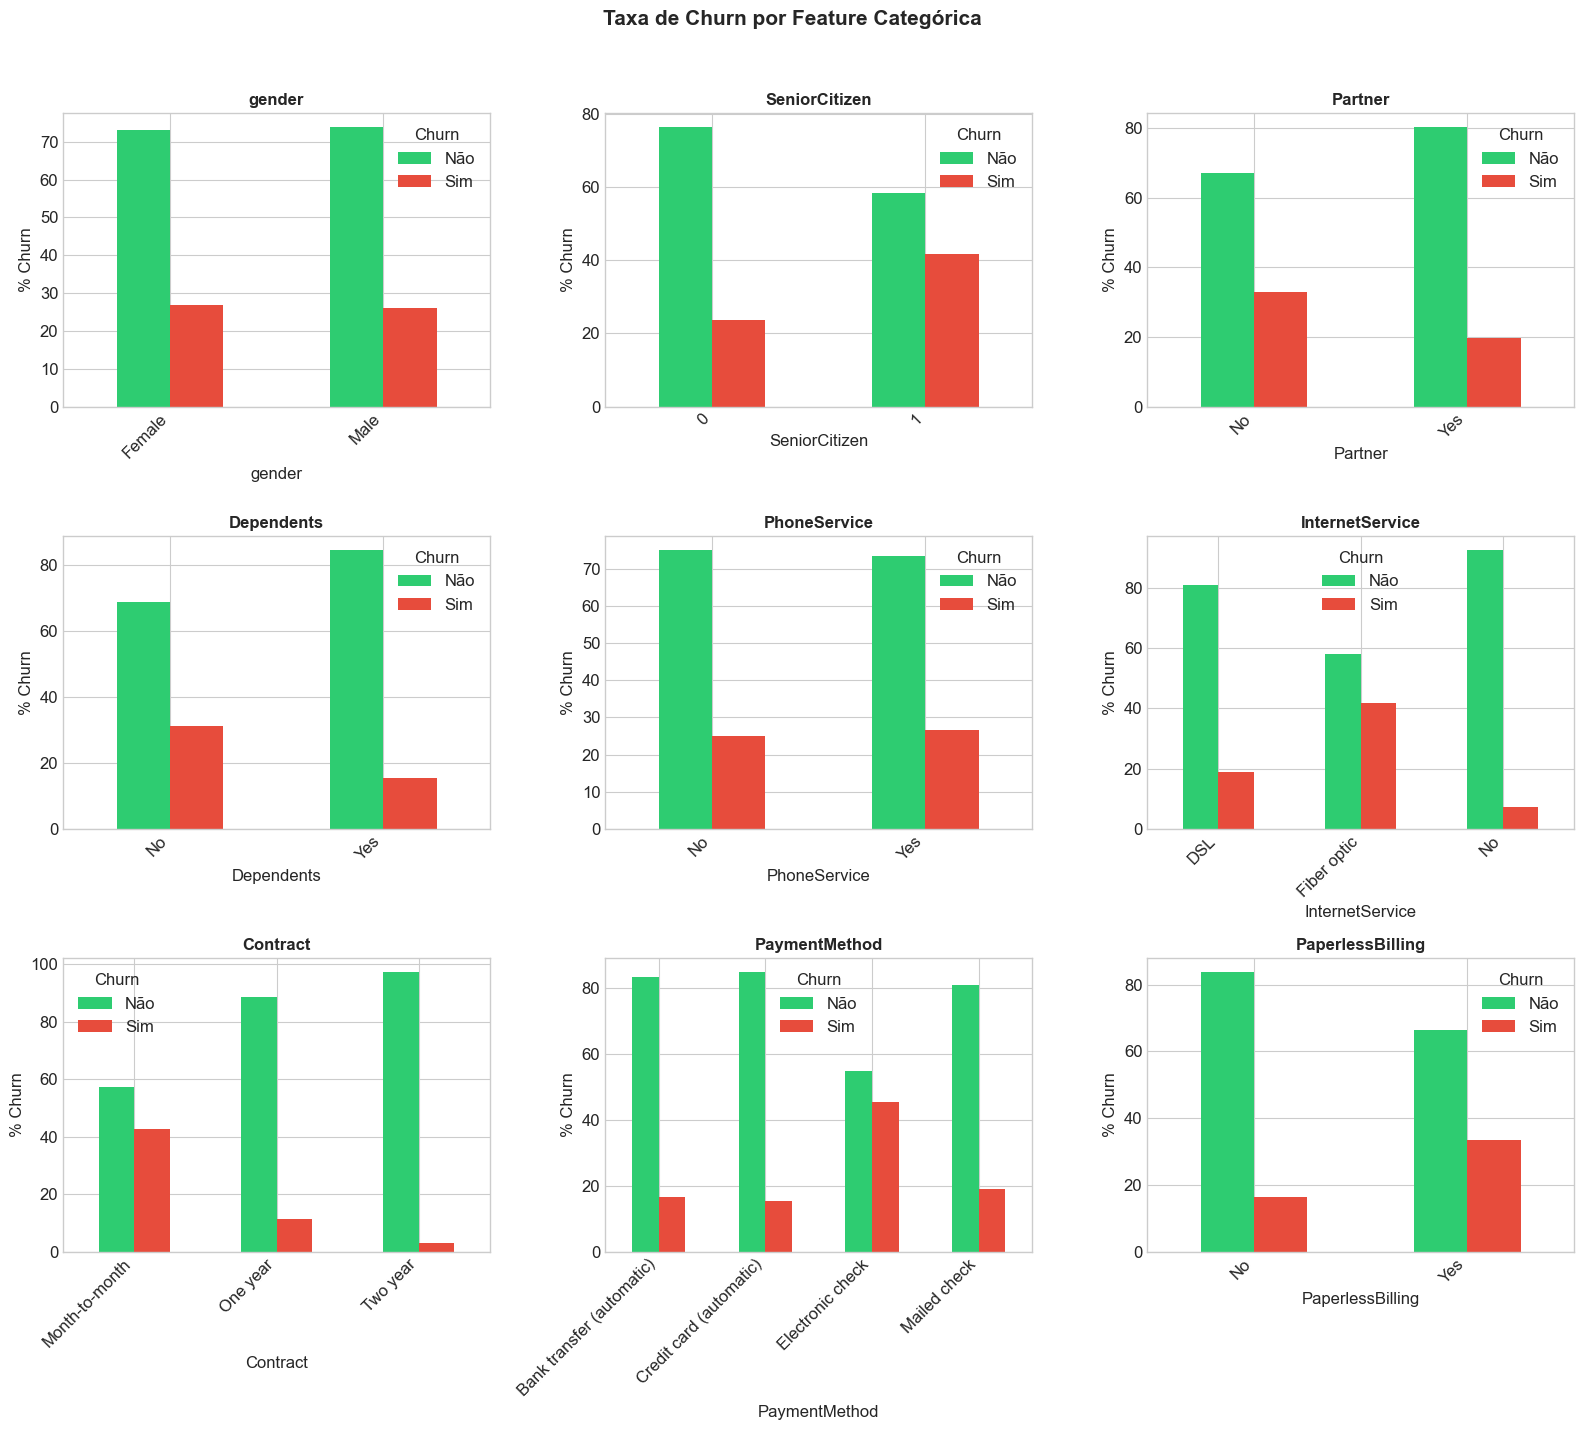

In [8]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'InternetService', 'Contract', 
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('% Churn')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].legend(['Não', 'Sim'], title='Churn')

plt.suptitle('Taxa de Churn por Feature Categórica', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

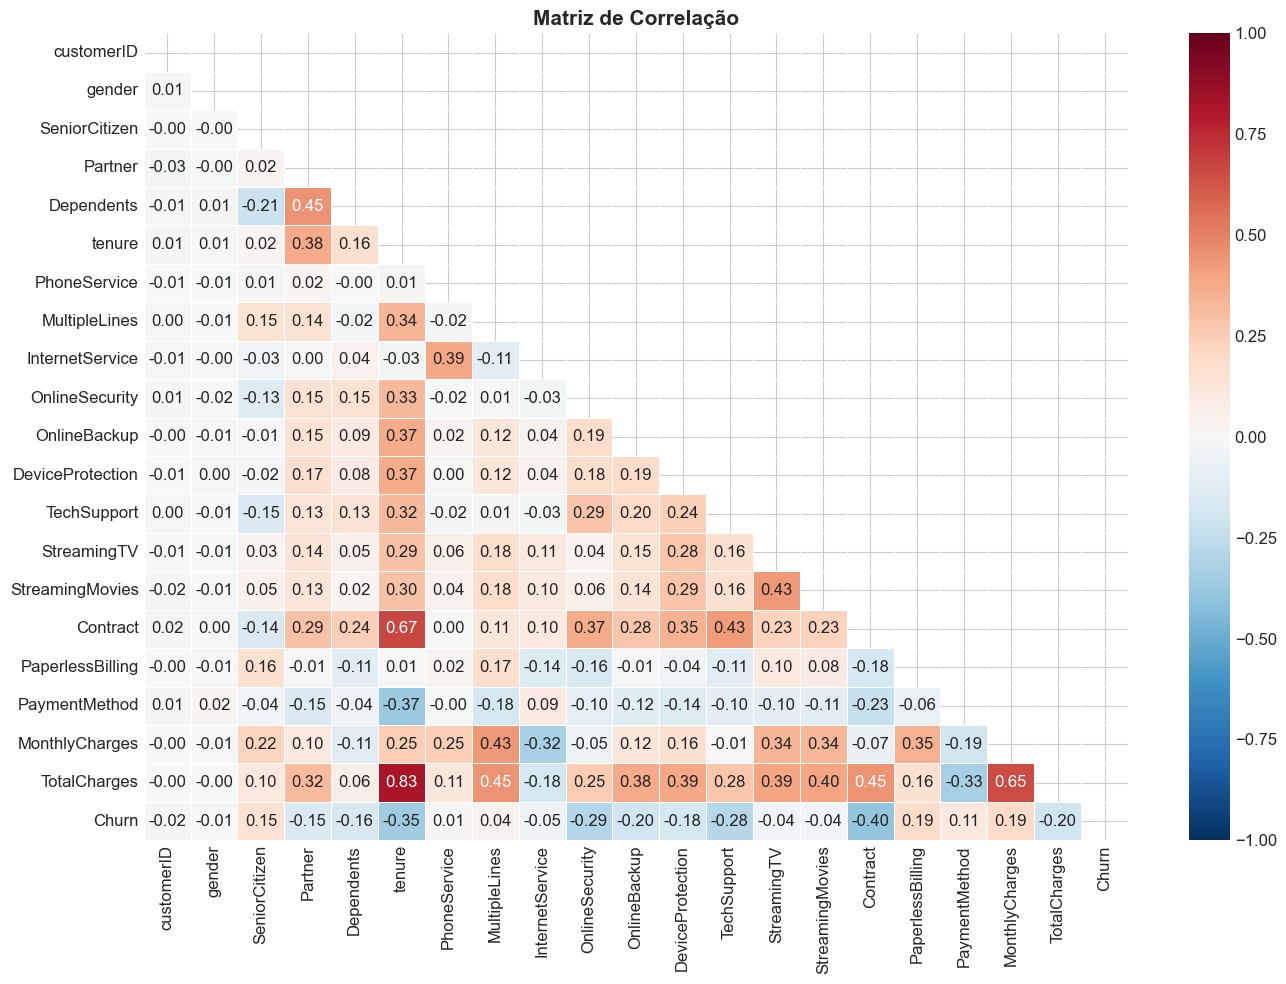


Top correlações com Churn:
Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.199037
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134
Dependents         -0.164221
Name: Churn, dtype: float64


In [9]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlações com Churn:")
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(10))

In [ ]:
print("=" * 60)
print("INSIGHTS DE NEGÓCIO — O QUE EU TIREI DA EDA")
print("=" * 60)
print(
    """
Anotei aqui os pontos que mais me chamaram atenção olhando os gráficos
e as tabelas acima. Não é uma lista exaustiva — são os padrões que achei
relevantes pro problema de churn e que acho que vão influenciar as
escolhas de modelagem mais pra frente.

1. DESBALANCEAMENTO: ~73.5% não cancelou vs ~26.5% cancelou.
   Percebi logo de cara que accuracy sozinha vai mentir aqui. Optei
   por usar F1, AUC-ROC e PR-AUC como métricas de referência.

2. TENURE: Clientes com poucos meses cancelam MUITO mais.
   Acredito que o primeiro ano é o momento crítico — qualquer ação
   de retenção provavelmente tem mais retorno nessa janela.

3. CONTRATO: Month-to-month cancela ~42% vs ~3% em contratos de 2 anos.
   Foi o sinal mais forte que encontrei. Contrato longo praticamente
   elimina churn — faz sentido pensar em incentivo pra migração.

4. INTERNET: Fiber Optic cancela mais que DSL.
   Achei curioso porque Fiber costuma ser o produto "premium".
   Minha hipótese é que está ligado ao preço mais alto ou a alguma
   insatisfação específica com o serviço — não dá pra afirmar só
   com esses dados.

5. PAGAMENTO: Electronic Check cancela mais (~45%).
   Desconfio que isso reflete mais perfil do cliente do que o método
   em si. Fica a observação pra não confundir correlação com causa.

6. MONTHLY CHARGES: Quem cancela paga em média mais caro.
   Combinado com o ponto do Fiber, reforça que preço pesa na decisão.

7. SENIOR CITIZEN: Idosos cancelam proporcionalmente mais.
   Registrei esse ponto porque me preocupa do lado de viés — vale
   voltar nisso quando for avaliar o modelo.
"""
)

In [ ]:
print("=" * 60)
print("DATA READINESS — MINHA AVALIAÇÃO DO DATASET")
print("=" * 60)
print(
    f"""
Antes de sair treinando qualquer coisa, quis fazer uma checagem honesta
de quão pronto esse dataset realmente está. Organizei por dimensão:

VOLUME: {df.shape[0]:,} registros e {df.shape[1]} features.
  Acho suficiente pro problema (>5000), embora não seja muito — imagino
  que com mais dados eu teria mais margem pra tentar modelos maiores.

QUALIDADE: Sem duplicatas e só 11 nulos em TotalCharges (que tratei
  com a mediana). Percebi que o dataset é bem "limpo", o que me deixa
  até um pouco desconfiado — dados reais de operadora dificilmente
  estariam assim.

BALANCEAMENTO: 73/27 é claramente desbalanceado. Não é extremo, mas
  o bastante pra eu ter que escolher métricas com cuidado.

FEATURES: Mix de numéricas e categóricas. Optei por seguir com MLP
  depois do pré-processamento (encoding + scaling), mas reconheço
  que pra esse tipo de dado modelos baseados em árvore também seriam
  candidatos naturais.

TARGET: Binária (Yes/No) — direto, sem ambiguidade.

CONCLUSÃO: Acredito que o dataset está pronto pra modelagem com
tratamento mínimo. Os próximos passos que planejei são pré-processar,
treinar baselines e só depois partir pra MLP.
"""
)